In [3]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.8 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np

from supabase import create_client

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.seasonal import STL

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [5]:
from dotenv import load_dotenv
import os
load_dotenv()

False

In [9]:
df_full = pd.read_csv("transactions.csv")

df_full.head()

,transaction_id,user_id,account_id,category_id,transaction_date,amount,transaction_type,merchant_name,description,running_balance,statement_id,transaction_hash,normalized_merchant
0,f6a0202e-809f-4e7a-ae9c-c90c24888214,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,eb8e56f1-9d69-4f53-89a4-056c4936d767,f89d39f0-2919-467d-9eae-73947cd92572,2025-06-09,59.0,expense,Zomato,Food & Drinks — Mon 09 Jun,8004.63,NaN,NaN,NaN
1,9cdaa5c8-3300-4183-8be7-3b80cbcd1ce8,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,eb8e56f1-9d69-4f53-89a4-056c4936d767,ee7c44a4-b997-4955-8565-e0095cc9a643,2025-06-09,204.0,expense,Uber,Transportation — Mon 09 Jun,7945.63,NaN,NaN,NaN
2,df32ac05-4a0e-48a7-aa54-8609a26747bb,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,eb8e56f1-9d69-4f53-89a4-056c4936d767,24e016a3-fafe-4519-8295-2f5f87ed7005,2025-06-09,4372.0,expense,Domino's,Food & Drinks — Mon 09 Jun,7741.63,NaN,NaN,NaN
3,1b546fbd-70c5-40fa-877b-15b5b994e969,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,eb8e56f1-9d69-4f53-89a4-056c4936d767,1623dc63-4f27-4f22-a699-fa2e66d0c14b,2025-06-09,42000.0,income,Employer Payroll,Monthly salary,3369.63,NaN,NaN,NaN
4,64178509-161e-49d6-86bc-2ffdcf8c4142,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,eb8e56f1-9d69-4f53-89a4-056c4936d767,825886bd-f63b-4c0f-9ac7-7f98670856c9,2025-06-10,1021.0,expense,INOX,Life & Entertainment — Tue 10 Jun,45369.63,NaN,NaN,NaN


In [10]:
df = df_full[["user_id", "transaction_date", "amount", "transaction_type"]]


In [11]:
df = df[
    df["transaction_type"] == "expense"
].copy()

df.shape

(293, 4)

In [12]:
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"]
)

df["amount"] = df["amount"].astype(float)

In [13]:
months_per_user = (
    df.groupby("user_id")
    ["transaction_date"]
    .apply(
        lambda x:
        x.dt.to_period("M").nunique()
    )
)

eligible_users = (
    months_per_user[
        months_per_user >= 6
    ]
    .index
)

len(eligible_users)

1

In [14]:
df = df[
    df["user_id"].isin(
        eligible_users
    )
]

df.shape

(293, 4)

In [15]:
monthly = (
    df.groupby(
        [
            "user_id",
            pd.Grouper(
                key="transaction_date",
                freq="MS"
            )
        ]
    )
    ["amount"]
    .sum()
    .reset_index()
)

monthly.columns = [
    "user_id",
    "month",
    "expense"
]

monthly.head(12)

,user_id,month,expense
0,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2025-06-01,26409.0
1,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2025-07-01,33569.0
2,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2025-08-01,27086.0
3,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2025-09-01,29949.0
4,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2025-10-01,31151.0
5,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2025-11-01,27326.0
6,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2025-12-01,35462.0
7,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2026-01-01,29723.0
8,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2026-02-01,33462.0
9,958b2a52-d1ea-4696-9f2d-09c5e90c5d24,2026-03-01,33247.0


In [16]:
print(
    "Users:",
    monthly.user_id.nunique()
)

print(
    "Rows:",
    len(monthly)
)

monthly.describe()

Users: 1
Rows: 13


,month,expense
count,13,13.000000
mean,2025-11-30 18:27:41.538461440,30588.461538
min,2025-06-01 00:00:00,26409.000000
25%,2025-09-01 00:00:00,28058.000000
50%,2025-12-01 00:00:00,30419.000000
75%,2026-03-01 00:00:00,33247.000000
max,2026-06-01 00:00:00,35462.000000
std,NaN,2853.162824


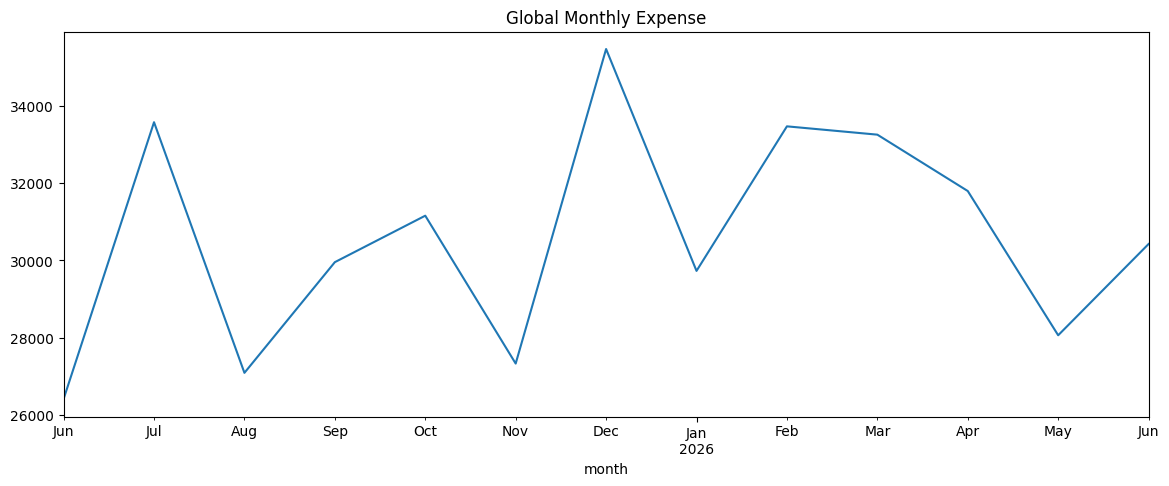

In [17]:
global_ts = (
    monthly.groupby("month")
    ["expense"]
    .sum()
)

plt.figure(figsize=(14,5))

global_ts.plot()

plt.title(
    "Global Monthly Expense"
)

plt.show()

In [18]:
monthly.groupby(
    "user_id"
)["expense"].describe()

,count,mean,std,min,25%,50%,75%,max
user_id,,,,,,,,
958b2a52-d1ea-4696-9f2d-09c5e90c5d24,13.0,30588.461538,2853.162824,26409.0,28058.0,30419.0,33247.0,35462.0


In [19]:
monthly["expense_norm"] = (
    monthly.groupby("user_id")
    ["expense"]
    .transform(
        lambda x:
        (x - x.mean())
        /
        x.std()
    )
)

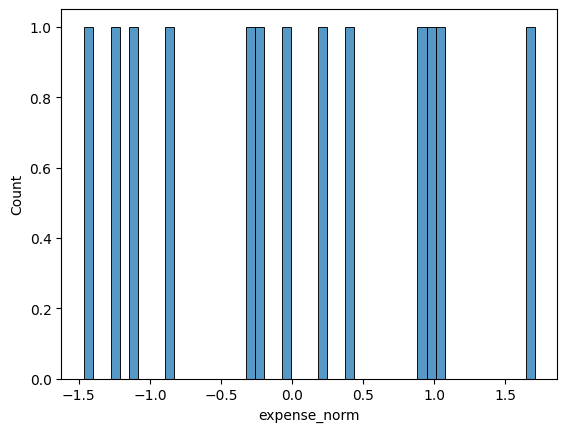

In [20]:
import seaborn as sns
sns.histplot(
    monthly["expense_norm"],
    bins=50
)

plt.show()

In [21]:
result = adfuller(global_ts)

print(
    "ADF Statistic:",
    result[0]
)

print(
    "P Value:",
    result[1]
)

ADF Statistic: -2.0930326581696144
P Value: 0.24732541838723426


## This means that the Expense series is **Not Stationary**

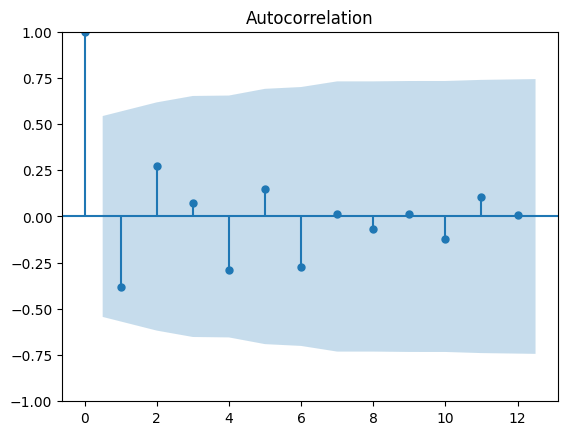

In [22]:
plot_acf(
    global_ts,
    lags=12
)

plt.show()

### Since no spikes go beyond the blue region:
Knowing expenses from previous months does not strongly help predict future months

In [23]:
print(len(global_ts))

13


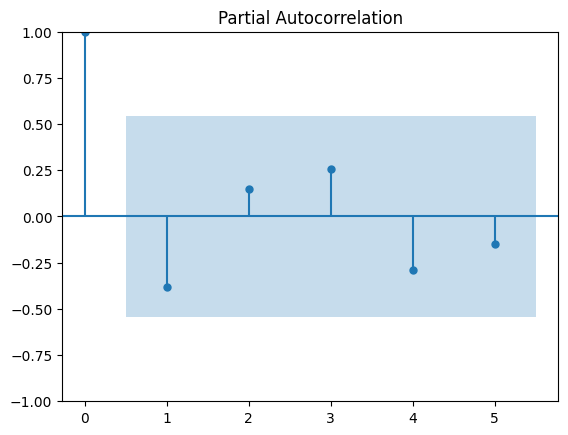

In [24]:

plot_pacf(
    global_ts,
    lags=5
)

plt.show()

### No direct lag is statistically significant.

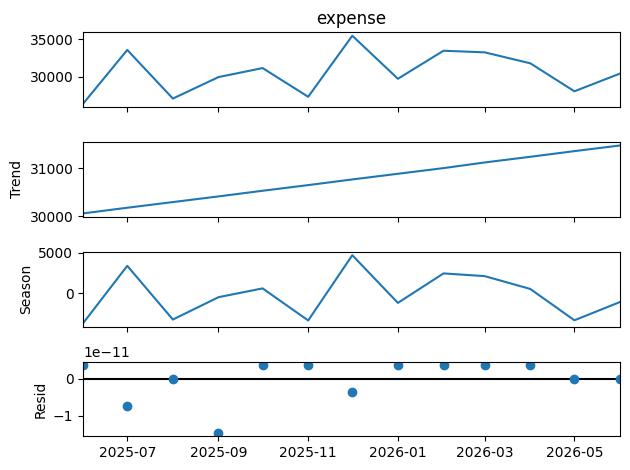

In [25]:
stl = STL(
    global_ts,
    period=12
)

res = stl.fit()

res.plot()

plt.show()

#### Trend present clearly: Not Stationary
#### Not enough evidence for monthly seasonality


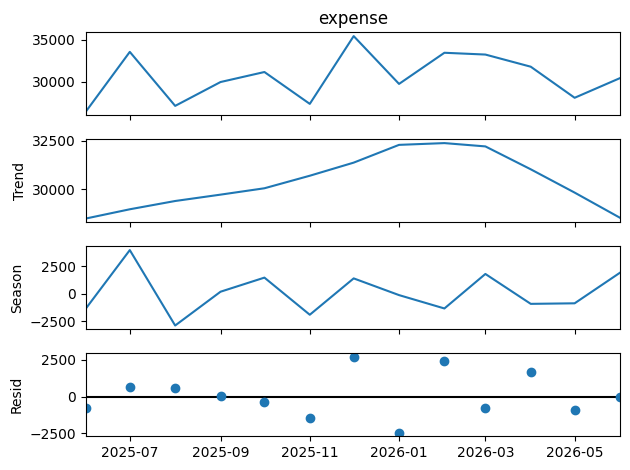

In [26]:
stl = STL(
    global_ts,
    period=3
)

res = stl.fit()

res.plot()

plt.show()

In [27]:
seasonality_strength = (
    np.var(res.seasonal)
    /
    (
        np.var(res.seasonal)
        +
        np.var(res.resid)
    )
)

seasonality_strength

0.6195028605933519

#### 62% of the data can be explained with seasonality, 38% other features: **Good Seasonality**

In [28]:
split = int(
    len(global_ts) * 0.6
)

train = global_ts[:split]

test = global_ts[split:]

In [29]:
pred_naive = np.repeat(
    train.iloc[-1],
    len(test)
)

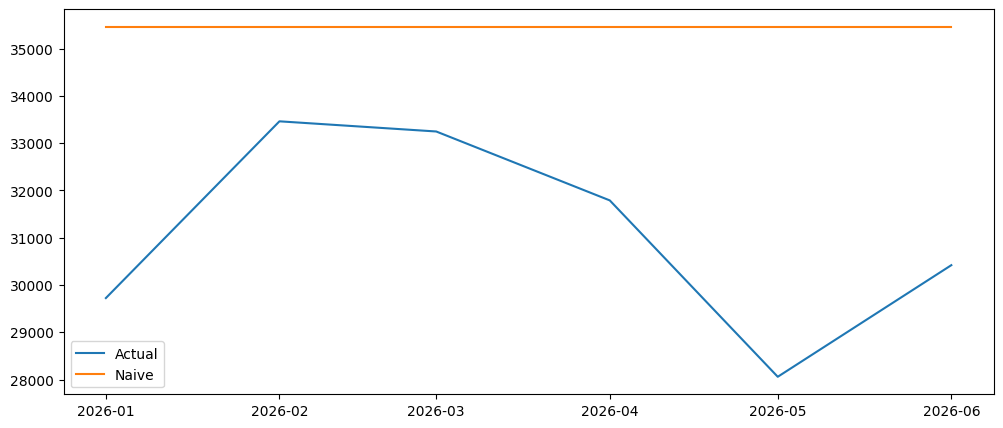

In [30]:
plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    pred_naive,
    label="Naive"
)

plt.legend()
plt.show()

In [31]:
arima = ARIMA(
    train,
    order=(1,1,1)
)

arima_fit = arima.fit()

pred_arima = arima_fit.forecast(
    len(test)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

In [32]:
arima_walk = ARIMA(
    train,
    order=(0,1,0)
)

arima_walk_fit = arima_walk.fit()

pred_arima_walk = arima_walk_fit.forecast(
    len(test)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [33]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,3)
)

sarima_fit = sarima.fit()

pred_sarima = sarima_fit.forecast(
    len(test)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/

In [34]:
sarimax = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarimax_fit = sarimax.fit()

pred_sarimax = sarimax_fit.forecast(
    len(test)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [35]:
prophet_df = (
    global_ts
    .reset_index()
)

prophet_df.columns = [
    "ds",
    "y"
]

train_prophet = prophet_df.iloc[:split]
test_prophet = prophet_df.iloc[split:]

model = Prophet()

prophet_model = Prophet()

model.fit(
    train_prophet
)

prophet_model.fit(
    train_prophet
)

future = model.make_future_dataframe(
    periods=len(test)
)

forecast = model.predict(
    future
)

pred_prophet = (
    forecast["yhat"]
    .tail(len(test))
)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.


#### Starting Feature Engineering for ML models

In [36]:
ml_df = monthly.copy()

for lag in [1,2,3,6]:
    ml_df[f"lag_{lag}"] = (
        ml_df.groupby("user_id")
        ["expense_norm"]
        .shift(lag)
    )

In [37]:
ml_df["rolling_mean_3"] = (
    ml_df.groupby("user_id")
    ["expense_norm"]
    .transform(
        lambda x:
        x.rolling(3).mean()
    )
)

ml_df["rolling_std_3"] = (
    ml_df.groupby("user_id")
    ["expense_norm"]
    .transform(
        lambda x:
        x.rolling(3).std()
    )
)

ml_df.dropna(inplace=True)

In [38]:
ml_df["month_num"] = (
    ml_df["month"]
    .dt.month
)

ml_df["quarter"] = (
    ml_df["month"]
    .dt.quarter
)

ml_df["year"] = (
    ml_df["month"]
    .dt.year
)

In [39]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_std_3",
    "month_num",
    "quarter"
]

target = "expense_norm"

split_date = (
    ml_df["month"]
    .quantile(0.8)
)

train_ml = ml_df[
    ml_df["month"] <= split_date
]

test_ml = ml_df[
    ml_df["month"] > split_date
]

In [40]:
lr = LinearRegression()

lr.fit(
    train_ml[features],
    train_ml[target]
)

pred_lr = lr.predict(
    test_ml[features]
)

In [41]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(
    train_ml[features],
    train_ml[target]
)

pred_rf = rf.predict(
    test_ml[features]
)

In [42]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(
    train_ml[features],
    train_ml[target]
)

pred_xgb = xgb.predict(
    test_ml[features]
)

In [43]:
def evaluate(
    y_true,
    y_pred,
    model
):
    return {
        "Model": model,
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "MAPE": mean_absolute_percentage_error(
            y_true,
            y_pred
        )*100
    }

In [44]:
results = []

results.append(
    evaluate(
        test,
        pred_naive,
        "Naive Forecast"
    )
)

results.append(
    evaluate(
        test,
        pred_arima,
        "ARIMA"
    )
)

results.append(
    evaluate(
        test,
        pred_arima_walk,
        "ARIMA_WALK"
    )
)

results.append(
    evaluate(
        test,
        pred_sarima,
        "SARIMA"
    )
)

"""
results.append(
    evaluate(
        test,
        pred_sarimax,
        "SARIMAX"
    )
)
"""

results.append(
    evaluate(
        test_prophet["y"],
        pred_prophet,
        "Prophet"
    )
)

results.append(
    evaluate(
        test_ml[target],
        pred_lr,
        "Linear Regression"
    )
)

results.append(
    evaluate(
        test_ml[target],
        pred_rf,
        "Random Forest"
    )
)

results.append(
    evaluate(
        test_ml[target],
        pred_xgb,
        "XGBoost"
    )
)

results_df = pd.DataFrame(
    results
)

results_df.sort_values(
    "MAPE"
)

,Model,MAE,RMSE,MAPE
4,Prophet,1867.036319,2221.391591,6.237203
1,ARIMA,4345.541118,4753.547517,14.410995
2,ARIMA_WALK,4345.666667,4753.671213,14.411404
0,Naive Forecast,4345.666667,4753.671213,14.411404
3,SARIMA,6444.099953,7539.914649,21.275200
7,XGBoost,1.189421,1.382414,514.979090
6,Random Forest,1.145081,1.265439,605.449457
5,Linear Regression,1.468541,1.652374,724.114635


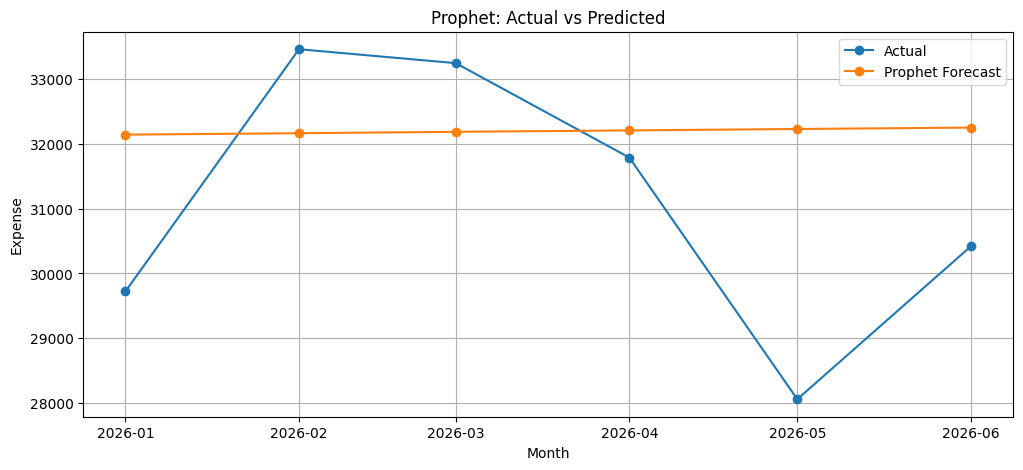

In [45]:
plt.figure(figsize=(12,5))

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Actual",
    marker="o"
)

plt.plot(
    test_prophet["ds"],
    pred_prophet,
    label="Prophet Forecast",
    marker="o"
)

plt.title(
    "Prophet: Actual vs Predicted"
)

plt.xlabel("Month")
plt.ylabel("Expense")

plt.legend()

plt.grid(True)

plt.show()

In [46]:
comparison = pd.DataFrame({
    "Date": test_prophet["ds"].values,
    "Actual": test_prophet["y"].values,
    "Predicted": pred_prophet.values
})

comparison

,Date,Actual,Predicted
0,2026-01-01,29723.0,32143.317141
1,2026-02-01,33462.0,32165.048655
2,2026-03-01,33247.0,32186.780170
3,2026-04-01,31789.0,32208.511685
4,2026-05-01,28058.0,32230.243199
5,2026-06-01,30419.0,32251.974714


In [47]:
prophet_model.params

OrderedDict([('lp__', array([[13.935295]])),
             ('k', array([[0.11214447]])),
             ('m', array([[0.79365852]])),
             ('delta',
              array([[-3.9873736e-10,  4.4068361e-11,  7.4223741e-11,  3.2723211e-10]])),
             ('sigma_obs', array([[0.08238239]])),
             ('beta', array([[2.9571765e-16]])),
             ('trend',
              array([[0.79365852, 0.81204286, 0.83104001, 0.85003716, 0.8684215 ,
                      0.88741865, 0.90580299]]))])